# Deliverable 2: Semantic Edge Annotation via Knowledge Distillation

This notebook implements a **Teacher-Student** approach to classify citation intents without exhausting our API limits. 

1. **Teacher**: We use **5 Gemma 3 models in parallel** (27B, 12B, 4B, 2B, 1B) — each with independent 30 RPM / 15K TPM / 14.4K RPD limits — to classify ~3,000 sampled edges at ~140 RPM combined.
2. **Student**: We fine-tune **SciBERT** (`allenai/scibert_scivocab_uncased`) on this labeled subset. 
3. **Inference**: We use the trained SciBERT model to quickly and freely classify the remaining 100,000+ edges.


In [1]:
import json
import random
import time
import os
import networkx as nx
import pandas as pd
import numpy as np
from tqdm import tqdm
import google.generativeai as genai
import community as community_louvain
import torch

from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    Trainer, 
    TrainingArguments
)
from datasets import Dataset

# ─── Teacher Model Configuration ───
# Gemma 3 27B: 14,400 RPD | 30 RPM | 15K TPM
# Full abstracts sent (~500 tokens/req). 3s delay keeps us within 15K TPM.
genai.configure(api_key="AQ.Ab8RN6JynwGLSwjvvdLY6UH0eKW5Na_I6-RlJov4B5r79dIZJg")

c:\Users\rocks\OneDrive\Desktop\NS-Project\.venv\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.0) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
c:\Users\rocks\OneDrive\Desktop\NS-Project\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\rocks\AppData\Local\Temp\ipykernel_26472\87456593.py:9: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See R

## 1. Data Loading & Graph Extraction

In [2]:
def reconstruct_abstract(indexed_abstract):
    """Reconstruct plain-text abstract from InvertedIndex format."""
    if not isinstance(indexed_abstract, dict) or 'InvertedIndex' not in indexed_abstract:
        return ""
    inv_idx = indexed_abstract['InvertedIndex']
    length = indexed_abstract.get('IndexLength', 0)
    if length == 0:
        max_idx = max([idx for indices in inv_idx.values() for idx in indices] + [-1])
        length = max_idx + 1
    if length == 0:
        return ""
    words = [""] * length
    for word, indices in inv_idx.items():
        for idx in indices:
            if idx < length: words[idx] = word
    return " ".join(words).strip()

papers = {}
data_path = 'data/sample_snowball_500k.json'

with open(data_path, 'r', encoding='utf-8') as f:
    data = json.load(f)
    for paper in tqdm(data, desc="Parsing Papers"):
        if 'id' in paper:
            papers[paper['id']] = {
                'title': paper.get('title', ''),
                'abstract': reconstruct_abstract(paper.get('indexed_abstract')),
                'references': paper.get('references', [])
            }

edges = []
for citing_id, citing_data in tqdm(papers.items(), desc="Closed-World Edges"):
    for cited_id in citing_data['references']:
        if cited_id in papers:
            edges.append((citing_id, cited_id))

print(f"Total papers: {len(papers)}")
print(f"Total closed-world edges: {len(edges)}")

Closed-World Edges: 100%|██████████| 500000/500000 [00:15<00:00, 33264.34it/s] 

Total papers: 500000
Total closed-world edges: 4871544


## 2. Generate Training Set using the Teacher (Multi-Model Concurrent)

**Strategy**: We use all 5 Gemma 3 variants (27B → 1B) with independent rate limits. Edges are round-robin distributed across models.  
**Rate math**: 5 models × 28 RPM each = ~140 RPM total, ~500 tokens/req per model stays under each model's 15K TPM.  
**Time**: 3,000 requests ÷ 140 RPM ≈ **~22 minutes** (vs ~150 min sequential).


In [5]:
TEACHER_SAMPLE_SIZE = 3000
random.seed(42)
sampled_edges = random.sample(edges, min(TEACHER_SAMPLE_SIZE, len(edges)))

LABELS = ['Background', 'Method', 'Result/Comparison', 'Support', 'Contrast/Criticism', 'Perfunctory/Ceremonial']
LABEL_MAP = {lbl: i for i, lbl in enumerate(LABELS)}
WEIGHT_MAP = {"Method": 1.0, "Result/Comparison": 0.7, "Support": 0.5,
              "Contrast/Criticism": 0.3, "Background": 0.2, "Perfunctory/Ceremonial": 0.1}

def call_teacher(citing_t, citing_a, cited_t, cited_a):
    """Classify citation intent using Gemma 3 27B with FULL abstracts."""
    prompt = (
        f"Classify this citation intent into EXACTLY ONE of: "
        f"{', '.join(LABELS)}.\n\n"
        f"Citing Paper Title: {citing_t}\n"
        f"Citing Paper Abstract: {citing_a}\n\n"
        f"Cited Paper Title: {cited_t}\n"
        f"Cited Paper Abstract: {cited_a}\n\n"
        f"Reply with ONLY the category name."
    )
    try:
        resp = teacher_model.generate_content(prompt)
        ans = resp.text.strip()
        # Handle minor formatting differences from LLM output
        for label in LABELS:
            if label.lower() in ans.lower():
                return label
    except Exception as e:
        print(f"API error: {e}")
    return "Background"  # safe fallback

In [4]:
# ─── Run Teacher Labeling: Multi-Model Concurrent ───
# Each Gemma 3 model has independent limits: 30 RPM / 15K TPM / 14.4K RPD
# 5 models × 28 RPM each = ~140 RPM total → ~22 min for 3000 labels
import threading
from concurrent.futures import ThreadPoolExecutor, as_completed

CHECKPOINT_PATH = 'data/teacher_labels_checkpoint.json'

MODEL_NAMES = [
    'gemma-3-27b-it',
    'gemma-3-12b-it',
    'gemma-3-4b-it',
    'gemma-3-2b-it',
    'gemma-3-1b-it',
]
models = [genai.GenerativeModel(name) for name in MODEL_NAMES]

class RateLimiter:
    def __init__(self, max_per_minute=28):
        self.interval = 60.0 / max_per_minute
        self.lock = threading.Lock()
        self.last_call = 0.0
    def wait(self):
        with self.lock:
            now = time.time()
            elapsed = now - self.last_call
            if elapsed < self.interval:
                time.sleep(self.interval - elapsed)
            self.last_call = time.time()

# One rate limiter per model
rate_limiters = [RateLimiter(max_per_minute=28) for _ in models]

# Resume from checkpoint
if os.path.exists(CHECKPOINT_PATH):
    with open(CHECKPOINT_PATH, 'r') as f:
        train_data = json.load(f)
    print(f"Resuming from checkpoint: {len(train_data)} labels already done.")
else:
    train_data = []

labeled_pairs = {(d['source'], d['target']) for d in train_data}
remaining = [(u, v) for u, v in sampled_edges if (u, v) not in labeled_pairs]
print(f"Remaining to label: {len(remaining)}")
print(f"Using {len(models)} models → ~{len(models)*28} RPM → ~{len(remaining)//(len(models)*28)} min estimated")

data_lock = threading.Lock()
progress = tqdm(total=len(remaining), desc="Teacher Labeling (5 Models)")

def call_with_model(model, citing_t, citing_a, cited_t, cited_a):
    prompt = (
        f"Classify this citation intent into EXACTLY ONE of: "
        f"{', '.join(LABELS)}.\n\n"
        f"Citing Paper Title: {citing_t}\n"
        f"Citing Paper Abstract: {citing_a}\n\n"
        f"Cited Paper Title: {cited_t}\n"
        f"Cited Paper Abstract: {cited_a}\n\n"
        f"Reply with ONLY the category name."
    )
    try:
        resp = model.generate_content(prompt)
        ans = resp.text.strip()
        for label in LABELS:
            if label.lower() in ans.lower():
                return label
    except Exception:
        pass
    return "Background"

def label_edge(idx, u, v):
    """Each edge is assigned to a model via round-robin."""
    mid = idx % len(models)
    rate_limiters[mid].wait()
    intent = call_with_model(
        models[mid],
        papers[u]['title'], papers[u]['abstract'],
        papers[v]['title'], papers[v]['abstract']
    )
    text_a = f"{papers[u]['title']}. {papers[u]['abstract']}"
    text_b = f"{papers[v]['title']}. {papers[v]['abstract']}"
    return {'text1': text_a, 'text2': text_b, 'label': LABEL_MAP[intent], 'source': u, 'target': v}

with ThreadPoolExecutor(max_workers=len(models) * 3) as executor:
    futures = {executor.submit(label_edge, i, u, v): (u, v) for i, (u, v) in enumerate(remaining)}
    for i, future in enumerate(as_completed(futures)):
        try:
            result = future.result()
            with data_lock:
                train_data.append(result)
            progress.update(1)
            if (i + 1) % 50 == 0:
                with data_lock:
                    with open(CHECKPOINT_PATH, 'w') as f:
                        json.dump(train_data, f)
                progress.write(f"  Checkpoint: {len(train_data)} labels done")
        except Exception as e:
            progress.write(f"  Error: {e}")

progress.close()

# Final save
with open(CHECKPOINT_PATH, 'w') as f:
    json.dump(train_data, f)

df_train = pd.DataFrame(train_data)
print(f"\nTotal: {len(train_data)} labels")
print(f"\nLabel distribution:\n{df_train['label'].map({v:k for k,v in LABEL_MAP.items()}).value_counts()}")


Remaining to label: 3000
Using 5 models → ~140 RPM → ~21 min estimated


Teacher Labeling (5 Models):   2%|▏         | 51/3000 [00:25<24:03,  2.04it/s]

  Checkpoint: 50 labels done


Teacher Labeling (5 Models):   3%|▎         | 100/3000 [00:51<17:49,  2.71it/s]

  Checkpoint: 100 labels done


...

  Checkpoint: 2900 labels done


Teacher Labeling (5 Models):  98%|█████████▊| 2951/3000 [26:51<00:39,  1.24it/s]

  Checkpoint: 2950 labels done


Teacher Labeling (5 Models): 100%|██████████| 3000/3000 [28:58<00:00,  1.73it/s]


  Checkpoint: 3000 labels done

Total: 3000 labels

Label distribution:
label
Background                1523
Result/Comparison          436
Support                    394
Method                     354
Contrast/Criticism         288
Perfunctory/Ceremonial       5
Name: count, dtype: int64


## 3. Train the Student Model (SciBERT)
SciBERT's tokenizer handles truncation automatically via `truncation=True, max_length=512`.

In [7]:
print(torch.__version__)
print(torch.cuda.is_available())

2.11.0+cu126
True


In [8]:
CHECKPOINT_PATH = 'data/teacher_labels_checkpoint.json'
with open(CHECKPOINT_PATH, 'r') as f:
    train_data = json.load(f)
df_train = pd.DataFrame(train_data)
print(f"Loaded {len(df_train)} labels")
print(df_train['label'].map({v:k for k,v in LABEL_MAP.items()}).value_counts())

MODEL_NAME = "allenai/scibert_scivocab_uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(examples['text1'], examples['text2'], padding="max_length", truncation=True, max_length=512)

dataset = Dataset.from_pandas(df_train[['text1', 'text2', 'label']])
tokenized_dataset = dataset.map(tokenize_function, batched=True)
tokenized_dataset = tokenized_dataset.train_test_split(test_size=0.1, seed=42)

student_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, 
    num_labels=len(LABELS)
)

# Confirm GPU is being used
print(f"Training on: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

training_args = TrainingArguments(
    output_dir="./scibert_citation_intent",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,    # 8 fits 4GB VRAM safely
    num_train_epochs=3,
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=50,
    fp16=True,                         # half precision → faster + less VRAM
)

trainer = Trainer(
    model=student_model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"]
)

print("Training the Student SciBERT Model...")
trainer.train()
print("Training complete!")


Loaded 3000 labels
label
Background                1523
Result/Comparison          436
Support                    394
Method                     354
Contrast/Criticism         288
Perfunctory/Ceremonial       5
Name: count, dtype: int64


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 18278.84it/s]
BertForSequenceClassification LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture

Training on: cuda
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
Training the Student SciBERT Model...


Epoch,Training Loss,Validation Loss
1,1.417195,1.418554
2,1.305496,1.422656
3,1.100866,1.479629


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.06it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

Training complete!


## 4. Inference on Full Dataset & Weighted Graph Construction
We use the fine-tuned SciBERT to classify all remaining edges for free.

In [7]:
MODEL_PATH = "./scibert_citation_intent/checkpoint-1014"  # adjust based on the listing above
tokenizer = AutoTokenizer.from_pretrained("allenai/scibert_scivocab_uncased")
student_model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
student_model = student_model.half().to(device)
student_model.eval()
print(f"Model loaded on: {next(student_model.parameters()).device}")


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1521.02it/s]


Model loaded on: cuda:0


In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
student_model.to(device)
student_model.eval()

EDGE_LIMIT = 5000  # set to len(edges) for full run
edges_subset = edges[:EDGE_LIMIT]

G_unweighted = nx.DiGraph()
G_weighted = nx.DiGraph()
all_intents = []
BATCH_SIZE = 32

print(f"Running inference on {len(edges_subset)} edges")

for i in tqdm(range(0, len(edges_subset), BATCH_SIZE), desc="Inference"):
    batch = edges_subset[i:i+BATCH_SIZE]
    t1 = [f"{papers[u]['title']}. {papers[u]['abstract']}" for u, v in batch]
    t2 = [f"{papers[v]['title']}. {papers[v]['abstract']}" for u, v in batch]
    
    # padding=True = pad to LONGEST in batch (not 512), max_length=256 = truncate early
    encodings = tokenizer(t1, t2, padding=True, truncation=True, max_length=256, return_tensors='pt')
    encodings = {k: v.to(device) for k, v in encodings.items()}
    
    with torch.no_grad(), torch.amp.autocast('cuda'):
        outputs = student_model(**encodings)
    preds = torch.argmax(outputs.logits, dim=-1).cpu().tolist()
    
    for (u, v), p in zip(batch, preds):
        intent = LABELS[p]
        G_unweighted.add_edge(u, v)
        G_weighted.add_edge(u, v, weight=WEIGHT_MAP[intent], intent=intent)
        all_intents.append(intent)

print(f"\nGraph: {G_weighted.number_of_nodes()} nodes, {G_weighted.number_of_edges()} edges")
print(f"\nIntent distribution:")
print(pd.Series(all_intents).value_counts())


Running inference on 5000 edges


Inference: 100%|██████████| 157/157 [00:29<00:00,  5.38it/s]


Graph: 3319 nodes, 5000 edges

Intent distribution:
Background           4686
Method                260
Result/Comparison      53
Support                 1
Name: count, dtype: int64


## 5. Network Analysis: Superficiality Ratio & PageRank Comparisons

In [21]:
print("Detecting communities for superficiality ratio...")
G_undirected = G_unweighted.to_undirected()
partition = community_louvain.best_partition(G_undirected)

communities = {}
for node, c_id in partition.items():
    communities.setdefault(c_id, []).append(node)

def compute_superficiality(c_nodes):
    """Fraction of shallow (Background + Perfunctory) citations within a community."""
    sg = G_weighted.subgraph(c_nodes)
    E = sg.number_of_edges()
    if E == 0: return 0.0
    shallow = sum(1 for u, v, d in sg.edges(data=True) if d['intent'] in ['Background', 'Perfunctory/Ceremonial'])
    return shallow / E

print("\n--- Community Superficiality Ratios (Top 10) ---")
sup_ratios = []
for c_id, nodes in communities.items():
    if len(nodes) > 2:
        r = compute_superficiality(nodes)
        sup_ratios.append((c_id, len(nodes), r))

sup_ratios.sort(key=lambda x: x[2], reverse=True)
for c_id, size, r in sup_ratios[:10]:
    flag = " POTENTIAL CARTEL" if r > 0.6 else ""
    print(f"  Community {c_id} ({size} nodes): Superficiality = {r:.2f}{flag}")

Detecting communities for superficiality ratio...

--- Community Superficiality Ratios (Top 10) ---
  Community 13 (81 nodes): Superficiality = 1.00 POTENTIAL CARTEL
  Community 14 (50 nodes): Superficiality = 1.00 POTENTIAL CARTEL
  Community 16 (116 nodes): Superficiality = 1.00 POTENTIAL CARTEL
  Community 24 (12 nodes): Superficiality = 1.00 POTENTIAL CARTEL
  Community 28 (32 nodes): Superficiality = 1.00 POTENTIAL CARTEL
  Community 30 (161 nodes): Superficiality = 1.00 POTENTIAL CARTEL
  Community 5 (8 nodes): Superficiality = 1.00 POTENTIAL CARTEL
  Community 8 (67 nodes): Superficiality = 1.00 POTENTIAL CARTEL
  Community 10 (4 nodes): Superficiality = 1.00 POTENTIAL CARTEL
  Community 15 (15 nodes): Superficiality = 1.00 POTENTIAL CARTEL


In [12]:
# ─── PageRank: Weighted vs Unweighted ───

pr_uw = nx.pagerank(G_unweighted)
pr_w = nx.pagerank(G_weighted, weight='weight')

df_pr = pd.DataFrame({
    'Paper_ID': list(pr_uw.keys()),
    'Title': [papers[n]['title'][:80] for n in pr_uw.keys()],
    'PR_Unweighted': list(pr_uw.values()),
    'PR_Weighted': [pr_w.get(n, 0) for n in pr_uw.keys()]
})

df_pr['Rank_Unweighted'] = df_pr['PR_Unweighted'].rank(ascending=False)
df_pr['Rank_Weighted'] = df_pr['PR_Weighted'].rank(ascending=False)
df_pr['Rank_Change'] = df_pr['Rank_Unweighted'] - df_pr['Rank_Weighted']

print("Papers with ARTIFICIALLY INFLATED centrality (dropped most when shallow citations downweighted):")
display(df_pr.sort_values('Rank_Change', ascending=True).head(10)[['Title', 'Rank_Unweighted', 'Rank_Weighted', 'Rank_Change']])

print("\nPapers with GENUINE deep impact (rose most when shallow citations downweighted):")
display(df_pr.sort_values('Rank_Change', ascending=False).head(10)[['Title', 'Rank_Unweighted', 'Rank_Weighted', 'Rank_Change']])

Papers with ARTIFICIALLY INFLATED centrality (dropped most when shallow citations downweighted):


,Title,Rank_Unweighted,Rank_Weighted,Rank_Change
847,Three-dimensional object recognition from sing...,659.5,1605.0,-945.5
848,Probabilistic object recognition using multidi...,659.5,1605.0,-945.5
844,Object Recognition Using Multidimensional Rece...,659.5,1605.0,-945.5
27,Recognition Using Region Correspondences,387.0,1313.0,-926.0
2246,Gene functional classification from heterogene...,974.5,1851.0,-876.5
575,An Application of Relaxation Labeling to Line ...,518.0,1292.5,-774.5
576,Elastic Matching of Line Drawings,518.0,1292.5,-774.5
577,An application of heuristic search methods to ...,518.0,1292.5,-774.5
574,Shape encoding and subjective contours,518.0,1292.5,-774.5
12,Shape recognition with edge-based features,524.0,1296.0,-772.0



Papers with GENUINE deep impact (rose most when shallow citations downweighted):


,Title,Rank_Unweighted,Rank_Weighted,Rank_Change
2717,Mining Mid-level Features for Image Classifica...,1958.0,632.0,1326.0
2247,Contour Tracking by Stochastic Propagation of ...,2030.0,786.0,1244.0
3193,Efficient spatiotemporal grouping using the Ny...,1672.5,439.0,1233.5
2792,VARIATIONAL ALGORITHMS FOR APPROXIMATE BAYESIA...,2304.5,1126.0,1178.5
3071,The discrete wavelet transform: wedding the a ...,2225.0,1053.5,1171.5
3075,The redundant discrete wavelet transform and a...,2225.0,1053.5,1171.5
1767,Orthogonal least squares learning algorithm fo...,1602.0,477.5,1124.5
1761,Training Multilayer Perceptrons with the Exten...,1602.0,477.5,1124.5
1730,Web-based 3D Reconstruction Service,1639.0,547.5,1091.5
3157,Space-time interest points,1912.0,831.0,1081.0


In [13]:
# ─── Save graphs for Deliverables 3 & 4 ───
import pickle

with open('data/weighted_citation_graph.gpickle', 'wb') as f:
    pickle.dump(G_weighted, f)
with open('data/unweighted_citation_graph.gpickle', 'wb') as f:
    pickle.dump(G_unweighted, f)
    
print("Graphs saved to data/ directory.")

Graphs saved to data/ directory.


In [14]:
# ─── Save graphs for Deliverables 3 & 4 ───
import json

# Save as GraphML (standard graph format)
nx.write_graphml(G_weighted, 'data/weighted_citation_graph.graphml')
nx.write_graphml(G_unweighted, 'data/unweighted_citation_graph.graphml')

# Also save as JSON edge list (easy to inspect and reload)
weighted_edges = [
    {'source': u, 'target': v, 'weight': d['weight'], 'intent': d['intent']}
    for u, v, d in G_weighted.edges(data=True)
]
with open('data/weighted_edges.json', 'w') as f:
    json.dump(weighted_edges, f)

print(f"Saved weighted graph: {G_weighted.number_of_nodes()} nodes, {G_weighted.number_of_edges()} edges")
print(f"Saved unweighted graph: {G_unweighted.number_of_nodes()} nodes, {G_unweighted.number_of_edges()} edges")
print("Files: data/weighted_citation_graph.graphml, data/unweighted_citation_graph.graphml, data/weighted_edges.json")


Saved weighted graph: 3319 nodes, 5000 edges
Saved unweighted graph: 3319 nodes, 5000 edges
Files: data/weighted_citation_graph.graphml, data/unweighted_citation_graph.graphml, data/weighted_edges.json


In [16]:
G_weighted = nx.read_graphml('data/weighted_citation_graph.graphml')
G_unweighted = nx.read_graphml('data/unweighted_citation_graph.graphml')


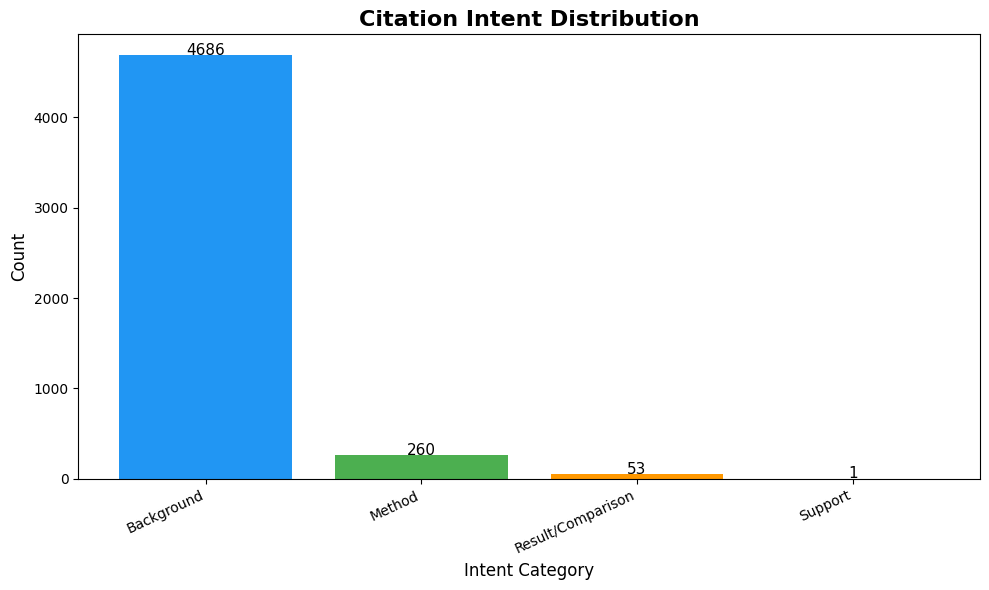

Saved: data/intent_distribution.png


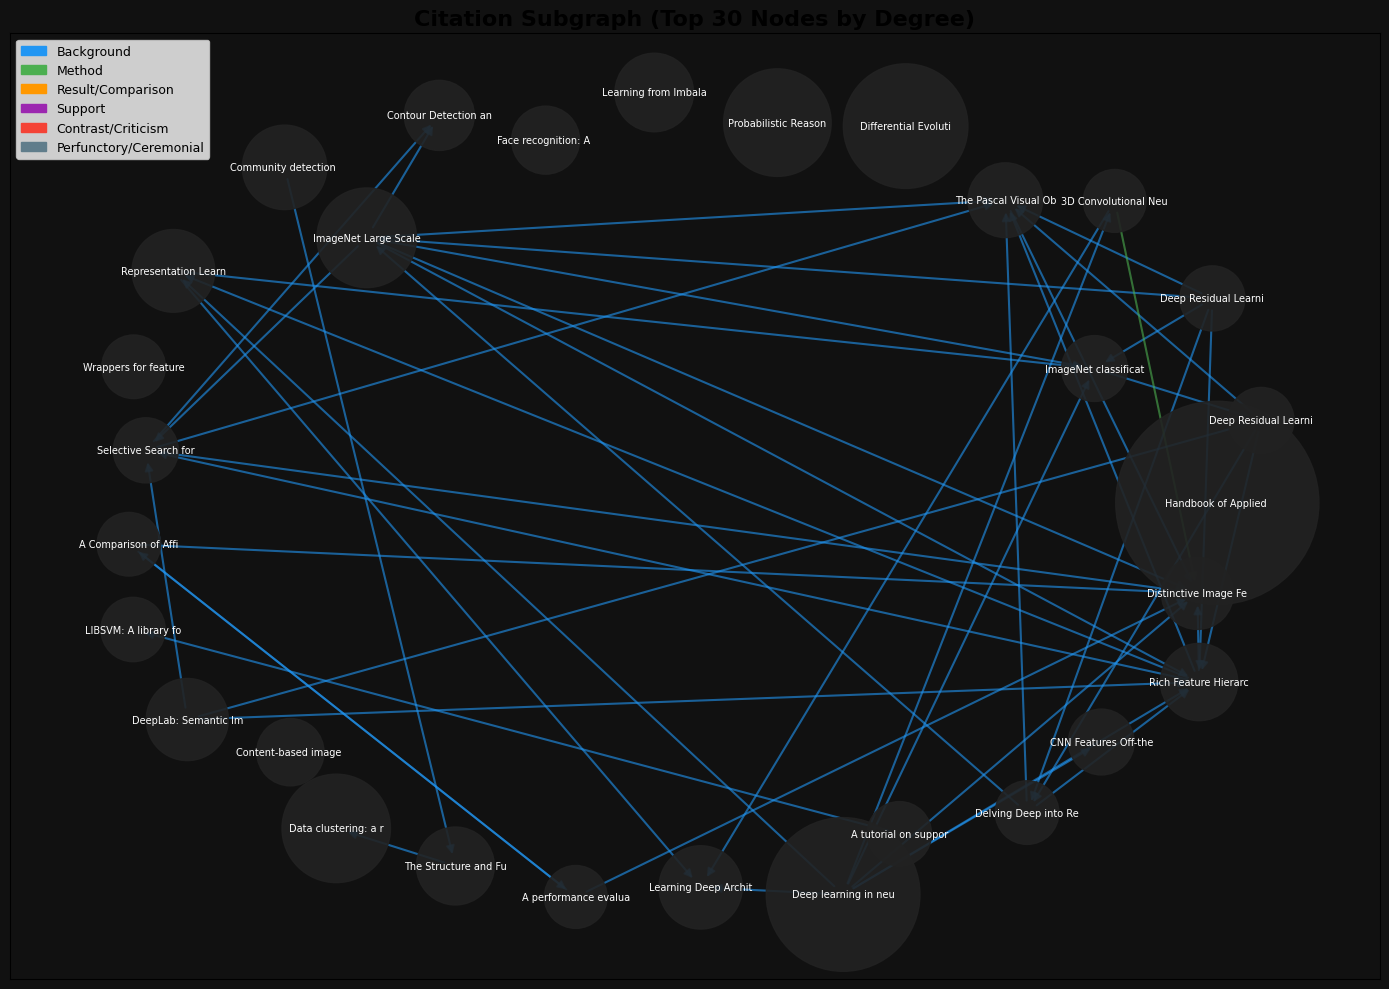

Saved: data/citation_subgraph.png


In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ─── 1. Intent Distribution Bar Chart ───
intent_counts = pd.Series(all_intents).value_counts()
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336', '#607D8B']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(intent_counts.index, intent_counts.values, color=colors[:len(intent_counts)])
ax.set_title('Citation Intent Distribution', fontsize=16, fontweight='bold')
ax.set_ylabel('Count', fontsize=12)
ax.set_xlabel('Intent Category', fontsize=12)
plt.xticks(rotation=25, ha='right')
for bar, val in zip(bars, intent_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(val), ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('data/intent_distribution.png', dpi=200)
plt.show()
print("Saved: data/intent_distribution.png")

# ─── 2. Subgraph Visualization (Top 30 nodes by degree) ───
top_nodes = sorted(G_weighted.nodes(), key=lambda n: G_weighted.degree(n), reverse=True)[:30]
subG = G_weighted.subgraph(top_nodes)

intent_colors = {
    'Background': '#2196F3', 'Method': '#4CAF50', 'Result/Comparison': '#FF9800',
    'Support': '#9C27B0', 'Contrast/Criticism': '#F44336', 'Perfunctory/Ceremonial': '#607D8B'
}
edge_colors = [intent_colors.get(subG[u][v].get('intent', 'Background'), '#999') for u, v in subG.edges()]

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(subG, k=2, seed=42)
node_sizes = [G_weighted.degree(n) * 50 + 100 for n in subG.nodes()]

nx.draw_networkx_nodes(subG, pos, node_size=node_sizes, node_color='#222', alpha=0.9, ax=ax)
nx.draw_networkx_edges(subG, pos, edge_color=edge_colors, alpha=0.6, width=1.5, arrows=True, arrowsize=12, ax=ax)
nx.draw_networkx_labels(subG, pos, labels={n: papers.get(n, papers.get(int(n) if str(n).isdigit() else n, {})).get('title', str(n))[:20] for n in subG.nodes()}, font_size=7, font_color='white', ax=ax)

patches = [mpatches.Patch(color=c, label=l) for l, c in intent_colors.items()]
ax.legend(handles=patches, loc='upper left', fontsize=9)
ax.set_title('Citation Subgraph (Top 30 Nodes by Degree)', fontsize=16, fontweight='bold')
ax.set_facecolor('#111')
fig.patch.set_facecolor('#111')
plt.tight_layout()
plt.savefig('data/citation_subgraph.png', dpi=200, facecolor='#111')
plt.show()
print("Saved: data/citation_subgraph.png")
